In [32]:
import sys

print("Python do notebook:")
print(sys.executable)

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units i
mport cm

print("\nReportLab OK")

SyntaxError: invalid syntax (1146286737.py, line 9)

In [33]:
from pathlib import Path
import json
import io
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image,
)

warnings.filterwarnings("ignore")

## 1. Configuração

Por padrão, o gerador procura os notebooks na mesma pasta deste arquivo ou na pasta anterior.  
Ajuste apenas os caminhos se a estrutura do repositório mudar.

In [34]:
ROOT = Path.cwd()

CANDIDATES = [
    ROOT / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT.parent / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT / "notebooks" / "05_bivariate_eda_collections_macro_analysis.ipynb",
]

BIVARIATE_NOTEBOOK = next((p for p in CANDIDATES if p.exists()), None)

if BIVARIATE_NOTEBOOK is None:
    raise FileNotFoundError(
        "Não encontrei 05_bivariate_eda_collections_macro_analysis.ipynb. "
        "Ajuste BIVARIATE_NOTEBOOK nesta célula."
    )

REPORT_DIR = ROOT / "reports"
CHART_DIR = REPORT_DIR / "collections_report_charts"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = REPORT_DIR / "collections_macro_bivariate_analysis_report.pdf"

print("Notebook fonte :", BIVARIATE_NOTEBOOK.resolve())
print("PDF de saída   :", PDF_PATH.resolve())

Notebook fonte : C:\Users\beelt\Documents\collections_case_candidate\notebooks\05_bivariate_eda_collections_macro_analysis.ipynb
PDF de saída   : C:\Users\beelt\Documents\collections_case_candidate\notebooks\reports\collections_macro_bivariate_analysis_report.pdf


In [35]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("../data")
QUEUE_PATH = DATA_DIR / "raw" / "collections_queue_sep2026.csv"
WA_PATH = DATA_DIR / "raw" / "whatsapp_collections_history.csv"

if not QUEUE_PATH.exists():
    QUEUE_PATH = Path("/mnt/data/collections_queue_sep2026(1).csv")
if not WA_PATH.exists():
    WA_PATH = Path("/mnt/data/whatsapp_collections_history(2).csv")

queue = pd.read_csv(QUEUE_PATH)
wa = pd.read_csv(WA_PATH)

wa["sent_at"] = pd.to_datetime(wa["sent_at"], errors="coerce")
queue["in_collections_since"] = pd.to_datetime(queue["in_collections_since"], errors="coerce")

print("Queue:", queue.shape)
print("WhatsApp:", wa.shape)

Queue: (10658, 10)
WhatsApp: (75406, 17)


##_______________________________________________________________________________________________________________________

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ============================================================
# LOAD
# ============================================================


df = wa

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["sent_date"] = df["sent_at"].dt.normalize()

df = (
    df
    .sort_values(["customer_id", "sent_at", "message_id"])
    .reset_index(drop=True)
)

print("Shape:", df.shape)
print("Customers:", df["customer_id"].nunique())
print("Period:", df["sent_at"].min(), "->", df["sent_at"].max())

df.head()

Shape: (75406, 18)
Customers: 11724
Period: 2026-06-01 09:18:00 -> 2026-08-31 20:59:00


,message_id,customer_id,sent_at,template,n_msgs_last_14d,days_past_due,outstanding_balance_brl,monthly_salary_brl,payday_day_of_month,n_prior_transactions,account_age_months,days_since_last_app_login,state_uf,delivery_status,interaction,paid_within_72h,amount_paid_brl,sent_date
0,M0018748,C000001,2026-07-06 13:29:00,pix_link,0,3,934.58,"1,680.00",5,5,2,38,ES,delivered,none,0,0.00,2026-07-06
1,M0019916,C000001,2026-07-07 14:48:00,friendly_reminder,1,4,934.58,"1,680.00",5,5,2,39,ES,delivered,clicked_link,0,0.00,2026-07-07
2,M0020536,C000001,2026-07-08 10:46:00,pix_link,2,5,934.58,"1,680.00",5,5,2,1,ES,delivered,none,0,0.00,2026-07-08
3,M0023754,C000001,2026-07-11 13:11:00,urgent_reminder,3,8,934.58,"1,680.00",5,5,2,4,ES,delivered,none,0,0.00,2026-07-11
4,M0027130,C000001,2026-07-15 12:54:00,urgent_reminder,4,12,934.58,"1,680.00",5,5,2,8,ES,delivered,none,0,0.00,2026-07-15


In [37]:
# ============================================================
# RECONSTRUCT COLLECTIONS ENTRY DATE
# ============================================================

df["implied_entry_date"] = (
    df["sent_date"]
    - pd.to_timedelta(
        np.maximum(df["days_past_due"] - 1, 0),
        unit="D"
    )
)

# Cada observação pode ter pequenas diferenças.
# Vamos pegar a mediana da data implícita por cliente.

entry = (
    df.groupby("customer_id", as_index=False)
      .agg(
          collections_entry_date=(
              "implied_entry_date",
              lambda x: pd.to_datetime(
                  int(x.astype("int64").median())
              ).normalize()
          )
      )
)

df = df.merge(entry, on="customer_id", how="left")

# Vintage mensal
df["vintage_month"] = (
    df["collections_entry_date"]
    .dt.to_period("M")
    .astype(str)
)

df[
    [
        "customer_id",
        "sent_date",
        "days_past_due",
        "collections_entry_date",
        "vintage_month"
    ]
].head(20)

,customer_id,sent_date,days_past_due,collections_entry_date,vintage_month
0,C000001,2026-07-06,3,2026-07-04,2026-07
1,C000001,2026-07-07,4,2026-07-04,2026-07
2,C000001,2026-07-08,5,2026-07-04,2026-07
3,C000001,2026-07-11,8,2026-07-04,2026-07
4,C000001,2026-07-15,12,2026-07-04,2026-07
5,C000001,2026-07-17,14,2026-07-04,2026-07
6,C000001,2026-07-29,26,2026-07-04,2026-07
7,C000002,2026-07-29,4,2026-07-26,2026-07
8,C000002,2026-07-30,5,2026-07-26,2026-07
9,C000002,2026-08-02,8,2026-07-26,2026-07


In [38]:
# ============================================================
# FINAL / CANONICAL VINTAGE DEFINITION
# ============================================================

customer_entry = (
    df.groupby("customer_id", as_index=False)
      .agg(
          collections_entry_date=("implied_entry_date", "first")
      )
)

# sanity check
consistency = (
    df.groupby("customer_id")["implied_entry_date"]
      .nunique()
)

assert consistency.max() == 1, \
    "Existe cliente com mais de uma entry date."

print("PASS — every customer has exactly one collections entry date.")

PASS — every customer has exactly one collections entry date.


In [39]:
# ============================================================
# VINTAGE CHECKPOINTS
# ============================================================

CHECKPOINTS = [7, 15, 30, 45, 60]

DATA_END = df["sent_date"].max()

print("Observation window ends:", DATA_END.date())

Observation window ends: 2026-08-31


In [40]:
# ============================================================
# CUSTOMER MATURITY
# ============================================================

customers = (
    df.groupby("customer_id", as_index=False)
      .agg(
          vintage_month=("vintage_month", "first"),
          collections_entry_date=("collections_entry_date", "first")
      )
)

customers["observable_days"] = (
    DATA_END - customers["collections_entry_date"]
).dt.days

for d in CHECKPOINTS:
    customers[f"mature_D{d}"] = (
        customers["observable_days"] >= d
    )

maturity_table = (
    customers.groupby("vintage_month")
    .agg(
        customers=("customer_id", "nunique"),
        mature_D7=("mature_D7", "sum"),
        mature_D15=("mature_D15", "sum"),
        mature_D30=("mature_D30", "sum"),
        mature_D45=("mature_D45", "sum"),
        mature_D60=("mature_D60", "sum")
    )
)

display(maturity_table)

,customers,mature_D7,mature_D15,mature_D30,mature_D45,mature_D60
vintage_month,,,,,,
2026-06,3966,3966,3966,3966,3966,3966
2026-07,4100,4100,4100,4100,2284,257
2026-08,3658,3034,2033,129,0,0


In [45]:
# ============================================================
# RECONSTRUCT COLLECTIONS ENTRY DATE
# ============================================================

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["days_past_due"] = pd.to_numeric(
    df["days_past_due"],
    errors="coerce"
)

# ------------------------------------------------------------
# 1. Infer entry date from each observation
#
# Convention:
# DPD 1 = first day in collections
#
# Therefore:
# entry_date = sent_date - (DPD - 1)
# ------------------------------------------------------------

df["in_collections_since"] = (
    df["sent_at"].dt.normalize()
    - pd.to_timedelta(df["days_past_due"] - 1, unit="D")
)


# ------------------------------------------------------------
# 2. Days since entry
#
# DPD 1 -> day 1
# DPD 15 -> day 15
# etc.
# ------------------------------------------------------------

df["days_since_entry"] = (
    df["sent_at"].dt.normalize()
    - df["in_collections_since"]
).dt.days + 1


# ============================================================
# VALIDATION
# ============================================================

check = (
    df["days_since_entry"] - df["days_past_due"]
).dropna()

print("=" * 80)
print("ENTRY DATE RECONSTRUCTION CHECK")
print("=" * 80)

print(f"Rows              : {len(df):,}")
print(f"Missing DPD       : {df['days_past_due'].isna().sum():,}")
print(f"Mismatch rows     : {(check != 0).sum():,}")
print(f"Max abs mismatch  : {check.abs().max()}")

assert (check == 0).all(), \
    "ERROR: days_since_entry does not reproduce days_past_due"

print("\nPASS — reconstructed journey day matches DPD exactly.")

ENTRY DATE RECONSTRUCTION CHECK
Rows              : 75,406
Missing DPD       : 0
Mismatch rows     : 0
Max abs mismatch  : 0

PASS — reconstructed journey day matches DPD exactly.


In [46]:
# ============================================================
# DAYS SINCE ENTRY
# ============================================================

df["sent_at"] = pd.to_datetime(df["sent_at"])
df["in_collections_since"] = pd.to_datetime(df["in_collections_since"])

df["days_since_entry"] = (
    df["sent_at"].dt.normalize()
    - df["in_collections_since"].dt.normalize()
).dt.days


# ============================================================
# SANITY CHECKS
# ============================================================

print("days_since_entry:")
print(df["days_since_entry"].describe())

print("\nMissing:")
print(df["days_since_entry"].isna().sum())

print("\nNegative values:")
print((df["days_since_entry"] < 0).sum())

display(
    df[
        [
            "customer_id",
            "in_collections_since",
            "sent_at",
            "days_since_entry",
            "amount_paid_brl"
        ]
    ].head(10)
)

# ============================================================
# FIRST PAYMENT
# ============================================================

payment_rows = df[
    df["amount_paid_brl"].fillna(0) > 0
].copy()

first_payment = (
    payment_rows
    .groupby("customer_id", as_index=False)
    .agg(
        first_payment_day=("days_since_entry", "min")
    )
)

customers = customers.merge(
    first_payment,
    on="customer_id",
    how="left"
)

# ============================================================
# VINTAGE PAYER CURVE
# ============================================================

results = []

for vintage in sorted(customers["vintage_month"].dropna().unique()):

    base = customers[
        customers["vintage_month"] == vintage
    ]

    for d in CHECKPOINTS:

        # IMPORTANT:
        # only customers who had enough observation time
        eligible = base[
            base["observable_days"] >= d
        ]

        if len(eligible) == 0:
            continue

        payers = (
            eligible["first_payment_day"].notna()
            &
            (eligible["first_payment_day"] <= d)
        ).sum()

        results.append({
            "vintage": vintage,
            "checkpoint": f"D+{d}",
            "eligible_customers": len(eligible),
            "payers": payers,
            "payer_rate_pct": 100 * payers / len(eligible)
        })

payer_vintage = pd.DataFrame(results)

display(payer_vintage)

days_since_entry:
count   75,406.00
mean        16.03
std         14.36
min          0.00
25%          5.00
50%         11.00
75%         24.00
max         59.00
Name: days_since_entry, dtype: float64

Missing:
0

Negative values:
0


,customer_id,in_collections_since,sent_at,days_since_entry,amount_paid_brl
0,C000001,2026-07-04,2026-07-06 13:29:00,2,0.00
1,C000001,2026-07-04,2026-07-07 14:48:00,3,0.00
2,C000001,2026-07-04,2026-07-08 10:46:00,4,0.00
3,C000001,2026-07-04,2026-07-11 13:11:00,7,0.00
4,C000001,2026-07-04,2026-07-15 12:54:00,11,0.00
5,C000001,2026-07-04,2026-07-17 12:54:00,13,0.00
6,C000001,2026-07-04,2026-07-29 09:14:00,25,934.58
7,C000002,2026-07-26,2026-07-29 10:31:00,3,0.00
8,C000002,2026-07-26,2026-07-30 09:31:00,4,0.00
9,C000002,2026-07-26,2026-08-02 10:54:00,7,0.00


,vintage,checkpoint,eligible_customers,payers,payer_rate_pct
0,2026-06,D+7,3966,815,20.55
1,2026-06,D+15,3966,1290,32.53
2,2026-06,D+30,3966,1634,41.20
3,2026-06,D+45,3966,1840,46.39
4,2026-06,D+60,3966,1948,49.12
5,2026-07,D+7,4100,814,19.85
6,2026-07,D+15,4100,1286,31.37
7,2026-07,D+30,4100,1632,39.80
8,2026-07,D+45,2284,1011,44.26
9,2026-07,D+60,257,129,50.19


In [47]:
payer_vintage_matrix = (
    payer_vintage
    .pivot(
        index="vintage",
        columns="checkpoint",
        values="payer_rate_pct"
    )
)

# ordenar corretamente
ordered_cols = [
    c for c in ["D+7", "D+15", "D+30", "D+45", "D+60"]
    if c in payer_vintage_matrix.columns
]

payer_vintage_matrix = payer_vintage_matrix[ordered_cols]

display(
    payer_vintage_matrix
    .round(1)
)

checkpoint,D+7,D+15,D+30,D+45,D+60
vintage,,,,,
2026-06,20.50,32.50,41.20,46.40,49.10
2026-07,19.90,31.40,39.80,44.30,50.20
2026-08,21.10,32.40,40.30,NaN,NaN


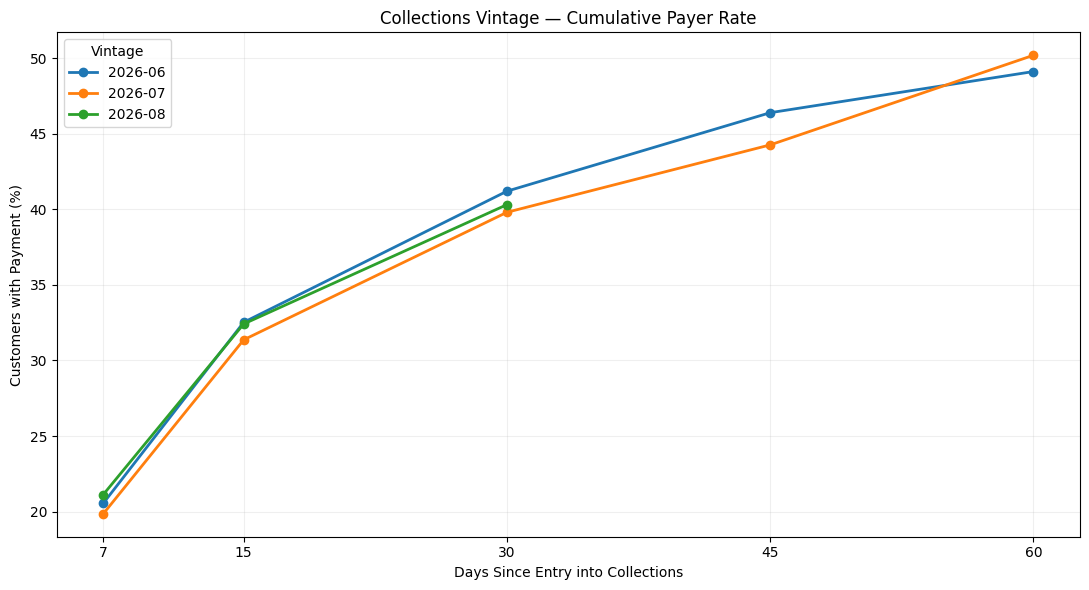

In [48]:
# ============================================================
# VINTAGE PAYER CURVES
# ============================================================

plt.figure(figsize=(11, 6))

for vintage, g in payer_vintage.groupby("vintage"):

    g = g.copy()

    g["day"] = (
        g["checkpoint"]
        .str.replace("D+", "", regex=False)
        .astype(int)
    )

    plt.plot(
        g["day"],
        g["payer_rate_pct"],
        marker="o",
        linewidth=2,
        label=vintage
    )

plt.title(
    "Collections Vintage — Cumulative Payer Rate"
)

plt.xlabel(
    "Days Since Entry into Collections"
)

plt.ylabel(
    "Customers with Payment (%)"
)

plt.xticks(CHECKPOINTS)

plt.legend(
    title="Vintage"
)

plt.grid(alpha=.2)

plt.tight_layout()

plt.show()

In [49]:
# ============================================================
# VINTAGE RECOVERY CURVE — R$
# ============================================================

results_recovery = []

for vintage in sorted(customers["vintage_month"].dropna().unique()):

    # Customers belonging to this vintage
    base = customers[
        customers["vintage_month"] == vintage
    ].copy()

    for d in CHECKPOINTS:

        # ----------------------------------------------------
        # Only customers with enough observation time
        # ----------------------------------------------------

        eligible = base[
            base["observable_days"] >= d
        ].copy()

        if len(eligible) == 0:
            continue

        eligible_ids = eligible["customer_id"]

        # ----------------------------------------------------
        # Payments observed up to checkpoint
        # ----------------------------------------------------

        payments_until_d = df[
            df["customer_id"].isin(eligible_ids)
            & (df["days_since_entry"] <= d)
            & (df["amount_paid_brl"].fillna(0) > 0)
        ]

        recovered_brl = (
            payments_until_d["amount_paid_brl"]
            .fillna(0)
            .sum()
        )

        results_recovery.append({
            "vintage": vintage,
            "checkpoint": f"D+{d}",
            "day": d,
            "eligible_customers": len(eligible),
            "recovered_brl": recovered_brl
        })


recovery_vintage = pd.DataFrame(results_recovery)

display(recovery_vintage)

,vintage,checkpoint,day,eligible_customers,recovered_brl
0,2026-06,D+7,7,3966,"552,410.77"
1,2026-06,D+15,15,3966,"900,959.34"
2,2026-06,D+30,30,3966,"1,173,910.96"
3,2026-06,D+45,45,3966,"1,337,596.51"
4,2026-06,D+60,60,3966,"1,422,950.51"
5,2026-07,D+7,7,4100,"535,967.90"
6,2026-07,D+15,15,4100,"865,812.16"
7,2026-07,D+30,30,4100,"1,125,650.56"
8,2026-07,D+45,45,2284,"698,171.91"
9,2026-07,D+60,60,257,"94,349.95"


In [52]:
# ============================================================
# INITIAL OUTSTANDING BALANCE PER CUSTOMER
# ============================================================

df = df.sort_values(
    ["customer_id", "sent_at"]
).copy()

initial_balance = (
    df
    .groupby("customer_id", as_index=False)
    .first()[
        [
            "customer_id",
            "outstanding_balance_brl"
        ]
    ]
    .rename(
        columns={
            "outstanding_balance_brl":
                "initial_outstanding_balance_brl"
        }
    )
)

# Avoid duplicate column if rerunning notebook
customers = customers.drop(
    columns=["initial_outstanding_balance_brl"],
    errors="ignore"
)

customers = customers.merge(
    initial_balance,
    on="customer_id",
    how="left"
)

print(
    customers["initial_outstanding_balance_brl"]
    .describe()
)

count   11,724.00
mean       850.01
std        485.33
min        250.00
25%        464.31
50%        751.18
75%      1,138.19
max      2,000.00
Name: initial_outstanding_balance_brl, dtype: float64


In [54]:
# ============================================================
# VINTAGE RECOVERY — R$ + OUTSTANDING BALANCE + RECOVERY %
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0. Ensure required types
# ------------------------------------------------------------

df["sent_at"] = pd.to_datetime(df["sent_at"])

df["amount_paid_brl"] = pd.to_numeric(
    df["amount_paid_brl"],
    errors="coerce"
).fillna(0)

df["outstanding_balance_brl"] = pd.to_numeric(
    df["outstanding_balance_brl"],
    errors="coerce"
)


# ------------------------------------------------------------
# 1. Initial outstanding balance per customer
#
# First observed balance in the collections journey
# ------------------------------------------------------------

initial_balance = (
    df
    .sort_values(["customer_id", "sent_at"])
    .groupby("customer_id", as_index=False)
    .first()[
        [
            "customer_id",
            "outstanding_balance_brl"
        ]
    ]
    .rename(columns={
        "outstanding_balance_brl":
            "initial_outstanding_balance_brl"
    })
)


# ------------------------------------------------------------
# 2. Add initial balance to customer-level table
# ------------------------------------------------------------

customers = customers.drop(
    columns=["initial_outstanding_balance_brl"],
    errors="ignore"
)

customers = customers.merge(
    initial_balance,
    on="customer_id",
    how="left"
)


# ------------------------------------------------------------
# 3. Build vintage recovery table
# ------------------------------------------------------------

results = []

for vintage in sorted(
    customers["vintage_month"].dropna().unique()
):

    base = customers[
        customers["vintage_month"] == vintage
    ].copy()

    for d in CHECKPOINTS:

        # ----------------------------------------------------
        # Customers with sufficient observation window
        # ----------------------------------------------------

        eligible = base[
            base["observable_days"] >= d
        ].copy()

        if len(eligible) == 0:
            continue

        eligible_ids = eligible["customer_id"]


        # ----------------------------------------------------
        # Initial outstanding balance
        # ----------------------------------------------------

        initial_outstanding = (
            eligible["initial_outstanding_balance_brl"]
            .fillna(0)
            .sum()
        )


        # ----------------------------------------------------
        # Payments accumulated through D+d
        # ----------------------------------------------------

        payment_mask = (
            df["customer_id"].isin(eligible_ids)
            &
            (df["days_since_entry"] <= d)
            &
            (df["amount_paid_brl"] > 0)
        )

        cumulative_recovery = (
            df.loc[
                payment_mask,
                "amount_paid_brl"
            ]
            .sum()
        )


        # ----------------------------------------------------
        # Recovery %
        # ----------------------------------------------------

        recovery_rate = (
            cumulative_recovery
            / initial_outstanding
            * 100
            if initial_outstanding > 0
            else np.nan
        )


        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        results.append({

            "vintage": vintage,

            "checkpoint": f"D+{d}",

            "day": d,

            "eligible_customers": len(eligible),

            "initial_outstanding_balance_brl":
                initial_outstanding,

            "cumulative_recovery_brl":
                cumulative_recovery,

            "recovery_rate_pct":
                recovery_rate
        })


# ------------------------------------------------------------
# 4. FINAL TABLE
# ------------------------------------------------------------

recovery_vintage = pd.DataFrame(results)


# ------------------------------------------------------------
# 5. VALIDATION
# ------------------------------------------------------------

required_cols = [
    "vintage",
    "day",
    "eligible_customers",
    "initial_outstanding_balance_brl",
    "cumulative_recovery_brl",
    "recovery_rate_pct"
]

missing = [
    c for c in required_cols
    if c not in recovery_vintage.columns
]

assert len(missing) == 0, (
    f"Missing columns: {missing}"
)

print("=" * 100)
print("VINTAGE RECOVERY TABLE")
print("=" * 100)

display(
    recovery_vintage[
        required_cols
    ].round(2)
)

VINTAGE RECOVERY TABLE


,vintage,day,eligible_customers,initial_outstanding_balance_brl,cumulative_recovery_brl,recovery_rate_pct
0,2026-06,7,3966,"3,350,930.37","552,410.77",16.49
1,2026-06,15,3966,"3,350,930.37","900,959.34",26.89
2,2026-06,30,3966,"3,350,930.37","1,173,910.96",35.03
3,2026-06,45,3966,"3,350,930.37","1,337,596.51",39.92
4,2026-06,60,3966,"3,350,930.37","1,422,950.51",42.46
5,2026-07,7,4100,"3,465,993.67","535,967.90",15.46
6,2026-07,15,4100,"3,465,993.67","865,812.16",24.98
7,2026-07,30,4100,"3,465,993.67","1,125,650.56",32.48
8,2026-07,45,2284,"1,893,916.51","698,171.91",36.86
9,2026-07,60,257,"215,464.54","94,349.95",43.79


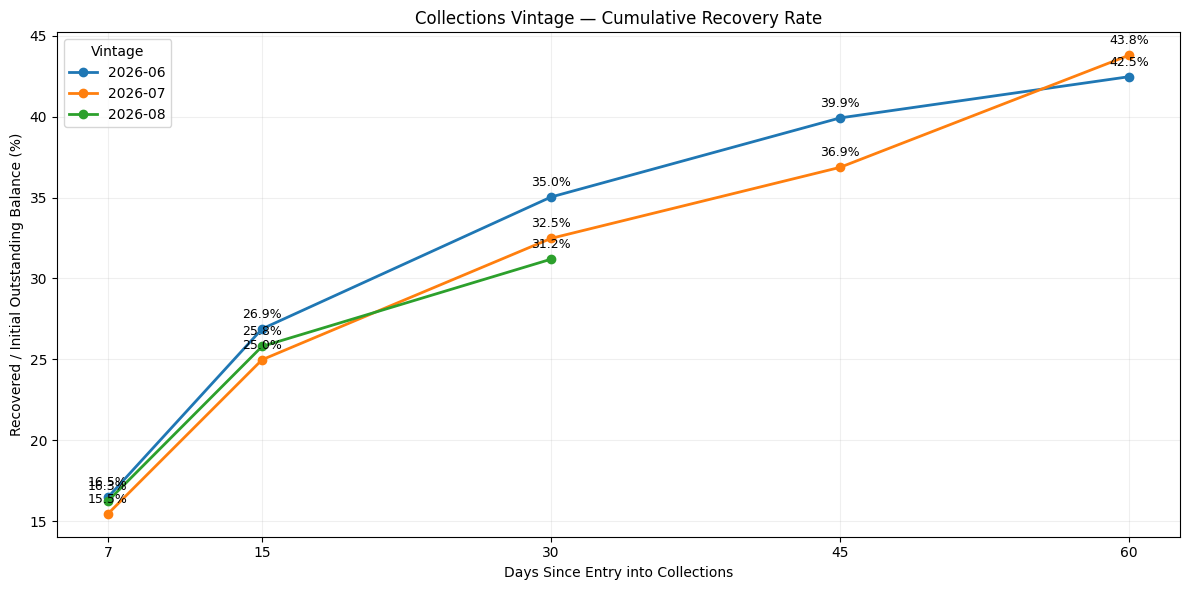

In [55]:
# ============================================================
# VINTAGE CURVE — CUMULATIVE RECOVERY %
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for vintage, g in recovery_vintage.groupby("vintage"):

    g = g.sort_values("day")

    plt.plot(
        g["day"],
        g["recovery_rate_pct"],
        marker="o",
        linewidth=2,
        label=str(vintage)
    )

    for _, row in g.iterrows():

        plt.annotate(
            f'{row["recovery_rate_pct"]:.1f}%',
            (
                row["day"],
                row["recovery_rate_pct"]
            ),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9
        )


plt.title(
    "Collections Vintage — Cumulative Recovery Rate"
)

plt.xlabel(
    "Days Since Entry into Collections"
)

plt.ylabel(
    "Recovered / Initial Outstanding Balance (%)"
)

plt.xticks(CHECKPOINTS)

plt.legend(
    title="Vintage"
)

plt.grid(alpha=.2)

plt.tight_layout()

plt.show()

In [56]:
# ============================================================
# TOTAL VINTAGE — ALL CUSTOMERS COMBINED
# ============================================================

results_total = []

for d in CHECKPOINTS:

    # --------------------------------------------------------
    # Only customers observable through this checkpoint
    # --------------------------------------------------------

    eligible = customers[
        customers["observable_days"] >= d
    ].copy()

    if len(eligible) == 0:
        continue

    eligible_ids = eligible["customer_id"]


    # --------------------------------------------------------
    # Initial outstanding balance
    # --------------------------------------------------------

    initial_outstanding = (
        eligible["initial_outstanding_balance_brl"]
        .fillna(0)
        .sum()
    )


    # --------------------------------------------------------
    # Cumulative recovery through checkpoint
    # --------------------------------------------------------

    payment_mask = (
        df["customer_id"].isin(eligible_ids)
        &
        (df["days_since_entry"] <= d)
        &
        (df["amount_paid_brl"] > 0)
    )

    cumulative_recovery = (
        df.loc[
            payment_mask,
            "amount_paid_brl"
        ]
        .sum()
    )


    # --------------------------------------------------------
    # Recovery rate
    # --------------------------------------------------------

    recovery_rate = (
        cumulative_recovery
        / initial_outstanding
        * 100
        if initial_outstanding > 0
        else np.nan
    )


    results_total.append({

        "vintage": "TOTAL",

        "checkpoint": f"D+{d}",

        "day": d,

        "eligible_customers": len(eligible),

        "initial_outstanding_balance_brl":
            initial_outstanding,

        "cumulative_recovery_brl":
            cumulative_recovery,

        "recovery_rate_pct":
            recovery_rate
    })


total_vintage = pd.DataFrame(results_total)

display(total_vintage.round(2))

,vintage,checkpoint,day,eligible_customers,initial_outstanding_balance_brl,cumulative_recovery_brl,recovery_rate_pct
0,TOTAL,D+7,7,11100,"9,434,953.17","1,513,947.79",16.05
1,TOTAL,D+15,15,10099,"8,580,212.87","2,221,784.40",25.89
2,TOTAL,D+30,30,8195,"6,924,087.28","2,332,986.91",33.69
3,TOTAL,D+45,45,6250,"5,244,846.88","2,035,768.42",38.81
4,TOTAL,D+60,60,4223,"3,566,394.91","1,517,300.46",42.54


In [57]:
# ============================================================
# GLOBAL CUMULATIVE RECOVERY CURVE — DPD 1 TO 60
# ============================================================

results_total_dpd = []

for d in range(1, 61):

    # --------------------------------------------------------
    # Customers with enough observation time to reach this DPD
    # --------------------------------------------------------

    eligible = customers[
        customers["observable_days"] >= d
    ].copy()

    if len(eligible) == 0:
        continue

    eligible_ids = eligible["customer_id"]


    # --------------------------------------------------------
    # Initial outstanding balance of eligible population
    # --------------------------------------------------------

    initial_outstanding = (
        eligible["initial_outstanding_balance_brl"]
        .fillna(0)
        .sum()
    )


    # --------------------------------------------------------
    # ALL recovery accumulated from DPD 1 through DPD d
    # --------------------------------------------------------

    cumulative_recovery = (
        df.loc[
            df["customer_id"].isin(eligible_ids)
            & (df["days_since_entry"] >= 1)
            & (df["days_since_entry"] <= d),
            "amount_paid_brl"
        ]
        .fillna(0)
        .sum()
    )


    # --------------------------------------------------------
    # % initial balance recovered
    # --------------------------------------------------------

    recovery_rate = (
        100 * cumulative_recovery / initial_outstanding
        if initial_outstanding > 0
        else np.nan
    )


    results_total_dpd.append({
        "day": d,
        "eligible_customers": len(eligible),
        "initial_outstanding_balance_brl": initial_outstanding,
        "cumulative_recovery_brl": cumulative_recovery,
        "recovery_rate_pct": recovery_rate
    })


total_dpd_curve = pd.DataFrame(results_total_dpd)

display(total_dpd_curve)

,day,eligible_customers,initial_outstanding_balance_brl,cumulative_recovery_brl,recovery_rate_pct
0,1,11688,"9,932,798.59","233,301.69",2.35
1,2,11624,"9,872,812.24","435,696.66",4.41
2,3,11547,"9,809,124.69","636,293.88",6.49
3,4,11436,"9,714,430.87","812,813.93",8.37
4,5,11340,"9,638,397.71","975,964.79",10.13
5,6,11235,"9,547,345.95","1,119,441.28",11.73
6,7,11100,"9,434,953.17","1,278,695.80",13.55
7,8,10968,"9,323,262.35","1,408,336.32",15.11
8,9,10833,"9,207,089.43","1,515,831.21",16.46
9,10,10714,"9,101,048.33","1,623,263.78",17.84


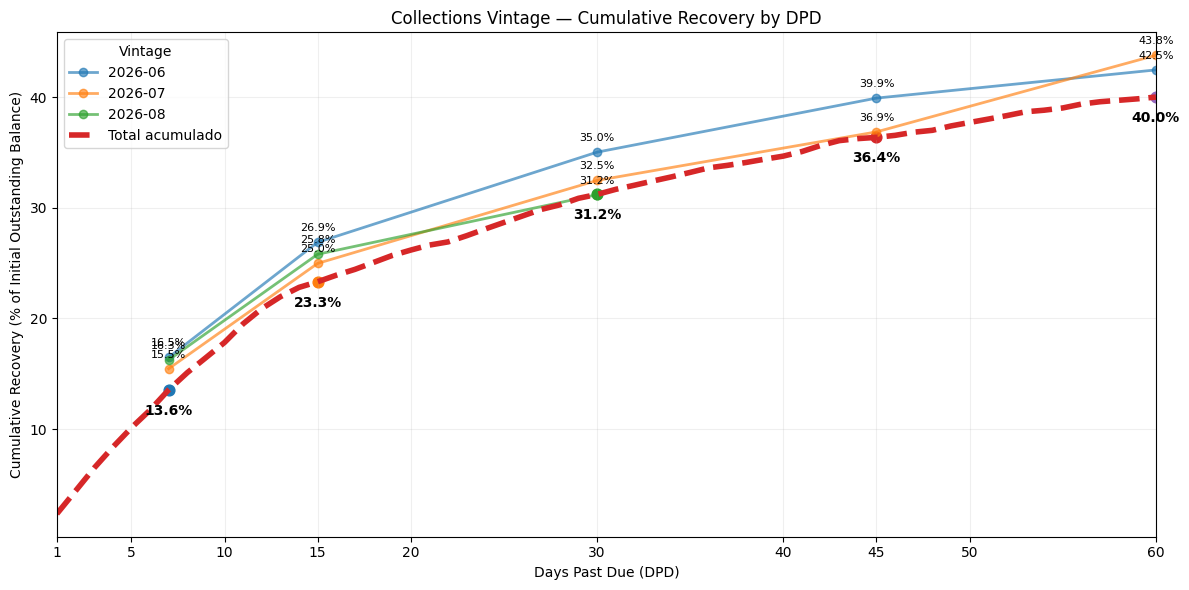

In [58]:
# ============================================================
# VINTAGE CHECKPOINTS + GLOBAL DPD 1–60 CURVE
# ============================================================

plt.figure(figsize=(12, 6))


# ------------------------------------------------------------
# MONTHLY VINTAGES
# ------------------------------------------------------------

for vintage, g in recovery_vintage.groupby("vintage"):

    g = g.sort_values("day")

    plt.plot(
        g["day"],
        g["recovery_rate_pct"],
        marker="o",
        linewidth=2,
        alpha=0.65,
        label=str(vintage)
    )

    for _, row in g.iterrows():

        plt.annotate(
            f'{row["recovery_rate_pct"]:.1f}%',
            (row["day"], row["recovery_rate_pct"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8
        )


# ------------------------------------------------------------
# GLOBAL CUMULATIVE CURVE — DPD 1 TO 60
# ------------------------------------------------------------

plt.plot(
    total_dpd_curve["day"],
    total_dpd_curve["recovery_rate_pct"],
    linewidth=4,
    linestyle="--",
    label="Total acumulado"
)


# ------------------------------------------------------------
# LABEL GLOBAL CURVE AT CHECKPOINTS
# ------------------------------------------------------------

for d in CHECKPOINTS:

    row = total_dpd_curve[
        total_dpd_curve["day"] == d
    ]

    if len(row) == 0:
        continue

    x = row["day"].iloc[0]
    y = row["recovery_rate_pct"].iloc[0]

    plt.scatter(
        x,
        y,
        s=60
    )

    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )


# ------------------------------------------------------------
# FORMATTING
# ------------------------------------------------------------

plt.title(
    "Collections Vintage — Cumulative Recovery by DPD"
)

plt.xlabel(
    "Days Past Due (DPD)"
)

plt.ylabel(
    "Cumulative Recovery (% of Initial Outstanding Balance)"
)

plt.xticks(
    [1, 5, 10, 15, 20, 30, 40, 45, 50, 60]
)

plt.xlim(1, 60)

plt.legend(
    title="Vintage"
)

plt.grid(alpha=.2)

plt.tight_layout()

plt.show()

In [59]:
# ============================================================
# GLOBAL CUMULATIVE RECOVERY CURVE
# FIXED INITIAL PORTFOLIO DENOMINATOR
# ============================================================

# ------------------------------------------------------------
# 1. Fixed initial portfolio balance
#    One initial balance per customer
# ------------------------------------------------------------

portfolio_initial_balance = (
    customers["initial_outstanding_balance_brl"]
    .fillna(0)
    .sum()
)

print(
    f"Initial portfolio balance: "
    f"R$ {portfolio_initial_balance:,.2f}"
)


# ------------------------------------------------------------
# 2. Total observed recovery
# ------------------------------------------------------------

portfolio_total_recovery = (
    df["amount_paid_brl"]
    .fillna(0)
    .sum()
)

print(
    f"Total recovery: "
    f"R$ {portfolio_total_recovery:,.2f}"
)

print(
    f"Total recovery rate: "
    f"{100 * portfolio_total_recovery / portfolio_initial_balance:.2f}%"
)

Initial portfolio balance: R$ 9,965,540.33
Total recovery: R$ 3,459,305.30
Total recovery rate: 34.71%


In [60]:
# ============================================================
# CUMULATIVE RECOVERY BY DPD
# DENOMINATOR FIXED AT INITIAL PORTFOLIO BALANCE
# ============================================================

results_total_dpd = []

for d in range(1, 61):

    cumulative_recovery = (
        df.loc[
            (df["days_since_entry"] <= d),
            "amount_paid_brl"
        ]
        .fillna(0)
        .sum()
    )

    recovery_rate = (
        100
        * cumulative_recovery
        / portfolio_initial_balance
    )

    results_total_dpd.append({
        "day": d,
        "cumulative_recovery_brl":
            cumulative_recovery,
        "recovery_rate_pct":
            recovery_rate
    })


total_dpd_curve = pd.DataFrame(
    results_total_dpd
)

In [61]:
# ============================================================
# CHECKPOINT VALIDATION
# ============================================================

display(
    total_dpd_curve[
        total_dpd_curve["day"].isin(
            [1, 7, 15, 30, 45, 60]
        )
    ]
)

print("\nDPD 60:")
print(
    total_dpd_curve[
        total_dpd_curve["day"] == 60
    ]
)

,day,cumulative_recovery_brl,recovery_rate_pct
0,1,"490,172.39",4.92
6,7,"1,570,858.13",15.76
14,15,"2,459,308.12",24.68
29,30,"3,049,653.12",30.60
44,45,"3,343,549.02",33.55
59,60,"3,459,305.30",34.71



DPD 60:
    day  cumulative_recovery_brl  recovery_rate_pct
59   60             3,459,305.30              34.71


In [62]:
print(
    df.loc[
        df["amount_paid_brl"] > 0,
        "days_since_entry"
    ].describe()
)

print(
    "\nRecovery after DPD 60:",
    df.loc[
        (df["days_since_entry"] > 60),
        "amount_paid_brl"
    ].sum()
)

count   5,626.00
mean       13.72
std        13.45
min         0.00
25%         4.00
50%         9.00
75%        20.00
max        59.00
Name: days_since_entry, dtype: float64

Recovery after DPD 60: 0.0


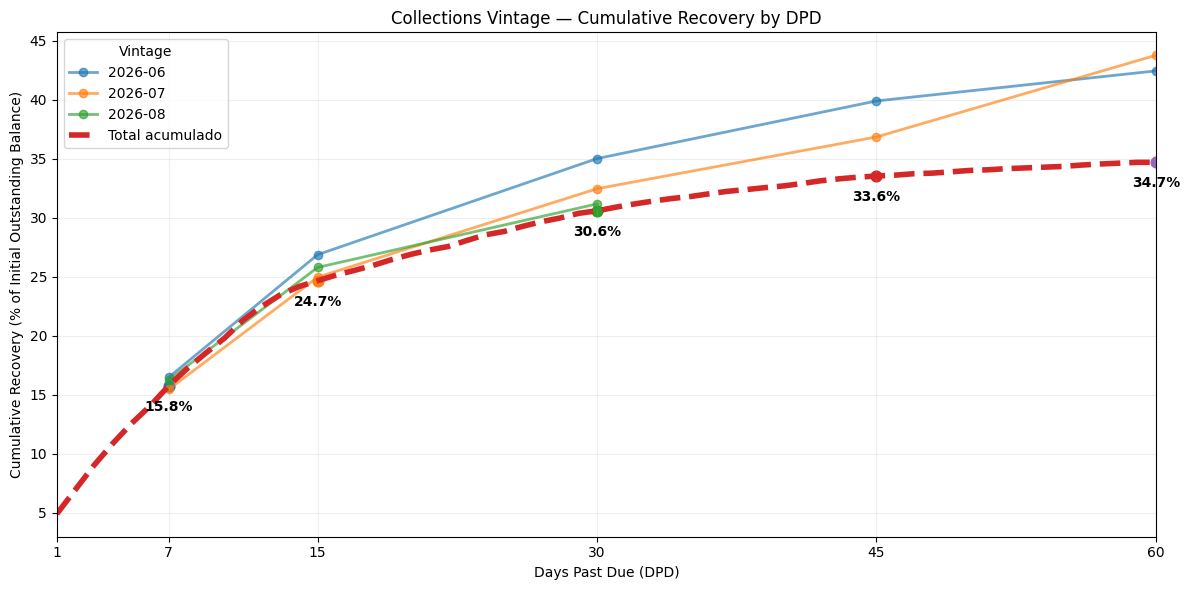

In [63]:
# ============================================================
# VINTAGES + TRUE PORTFOLIO CUMULATIVE RECOVERY
# ============================================================

plt.figure(figsize=(12, 6))


# ------------------------------------------------------------
# MONTHLY VINTAGES
# ------------------------------------------------------------

for vintage, g in recovery_vintage.groupby("vintage"):

    g = g.sort_values("day")

    plt.plot(
        g["day"],
        g["recovery_rate_pct"],
        marker="o",
        linewidth=2,
        alpha=.65,
        label=str(vintage)
    )


# ------------------------------------------------------------
# TOTAL PORTFOLIO — FIXED DENOMINATOR
# ------------------------------------------------------------

plt.plot(
    total_dpd_curve["day"],
    total_dpd_curve["recovery_rate_pct"],
    linewidth=4,
    linestyle="--",
    label="Total acumulado"
)


# ------------------------------------------------------------
# TOTAL LABELS
# ------------------------------------------------------------

for d in [7, 15, 30, 45, 60]:

    row = total_dpd_curve[
        total_dpd_curve["day"] == d
    ]

    if len(row) == 0:
        continue

    y = row["recovery_rate_pct"].iloc[0]

    plt.scatter(
        d,
        y,
        s=60
    )

    plt.annotate(
        f"{y:.1f}%",
        (d, y),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )


plt.title(
    "Collections Vintage — Cumulative Recovery by DPD"
)

plt.xlabel(
    "Days Past Due (DPD)"
)

plt.ylabel(
    "Cumulative Recovery (% of Initial Outstanding Balance)"
)

plt.xticks(
    [1, 7, 15, 30, 45, 60]
)

plt.xlim(1, 60)

plt.legend(
    title="Vintage"
)

plt.grid(alpha=.2)

plt.tight_layout()

plt.show()

In [64]:
# ============================================================
# VINTAGE RECOVERY CURVES
# FIXED DENOMINATOR WITHIN EACH VINTAGE
# ============================================================

results_vintage = []

for vintage in sorted(
    customers["vintage_month"].dropna().unique()
):

    # --------------------------------------------------------
    # 1. FIXED POPULATION FOR THIS VINTAGE
    # --------------------------------------------------------

    vintage_customers = customers[
        customers["vintage_month"] == vintage
    ].copy()

    vintage_ids = vintage_customers["customer_id"]


    # --------------------------------------------------------
    # 2. FIXED INITIAL BALANCE FOR THIS VINTAGE
    #
    # IMPORTANT:
    # this denominator NEVER changes across DPD
    # --------------------------------------------------------

    vintage_initial_balance = (
        vintage_customers[
            "initial_outstanding_balance_brl"
        ]
        .fillna(0)
        .sum()
    )


    # --------------------------------------------------------
    # 3. RECOVERY CURVE DPD 1 → 60
    # --------------------------------------------------------

    for d in range(1, 61):

        cumulative_recovery = (
            df.loc[
                df["customer_id"].isin(vintage_ids)
                &
                (df["days_since_entry"] <= d),
                "amount_paid_brl"
            ]
            .fillna(0)
            .sum()
        )


        recovery_rate = (
            100
            * cumulative_recovery
            / vintage_initial_balance
            if vintage_initial_balance > 0
            else np.nan
        )


        results_vintage.append({

            "vintage": vintage,

            "day": d,

            "customers":
                len(vintage_customers),

            "initial_outstanding_balance_brl":
                vintage_initial_balance,

            "cumulative_recovery_brl":
                cumulative_recovery,

            "recovery_rate_pct":
                recovery_rate
        })


recovery_vintage = pd.DataFrame(
    results_vintage
)

In [65]:
# ============================================================
# VALIDATION — DENOMINATOR MUST BE FIXED
# ============================================================

denominator_check = (
    recovery_vintage
    .groupby("vintage")
    .agg(
        customers=("customers", "first"),

        initial_balance_min=(
            "initial_outstanding_balance_brl",
            "min"
        ),

        initial_balance_max=(
            "initial_outstanding_balance_brl",
            "max"
        )
    )
    .reset_index()
)

denominator_check["difference"] = (
    denominator_check["initial_balance_max"]
    -
    denominator_check["initial_balance_min"]
)

display(denominator_check)

assert (
    denominator_check["difference"].abs() < 0.01
).all()

print(
    "PASS — denominator is fixed within every vintage."
)

,vintage,customers,initial_balance_min,initial_balance_max,difference
0,2026-06,3966,"3,350,930.37","3,350,930.37",0.00
1,2026-07,4100,"3,465,993.67","3,465,993.67",0.00
2,2026-08,3658,"3,148,616.29","3,148,616.29",0.00


PASS — denominator is fixed within every vintage.


In [66]:
# ============================================================
# VINTAGE CHECKPOINT TABLE
# ============================================================

checkpoints_table = (
    recovery_vintage[
        recovery_vintage["day"].isin(
            [7, 15, 30, 45, 60]
        )
    ]
    [
        [
            "vintage",
            "day",
            "customers",
            "initial_outstanding_balance_brl",
            "cumulative_recovery_brl",
            "recovery_rate_pct"
        ]
    ]
)

display(
    checkpoints_table.round(2)
)

,vintage,day,customers,initial_outstanding_balance_brl,cumulative_recovery_brl,recovery_rate_pct
6,2026-06,7,3966,"3,350,930.37","552,410.77",16.49
14,2026-06,15,3966,"3,350,930.37","900,959.34",26.89
29,2026-06,30,3966,"3,350,930.37","1,173,910.96",35.03
44,2026-06,45,3966,"3,350,930.37","1,337,596.51",39.92
59,2026-06,60,3966,"3,350,930.37","1,422,950.51",42.46
66,2026-07,7,4100,"3,465,993.67","535,967.90",15.46
74,2026-07,15,4100,"3,465,993.67","865,812.16",24.98
89,2026-07,30,4100,"3,465,993.67","1,125,650.56",32.48
104,2026-07,45,4100,"3,465,993.67","1,255,860.91",36.23
119,2026-07,60,4100,"3,465,993.67","1,286,263.19",37.11


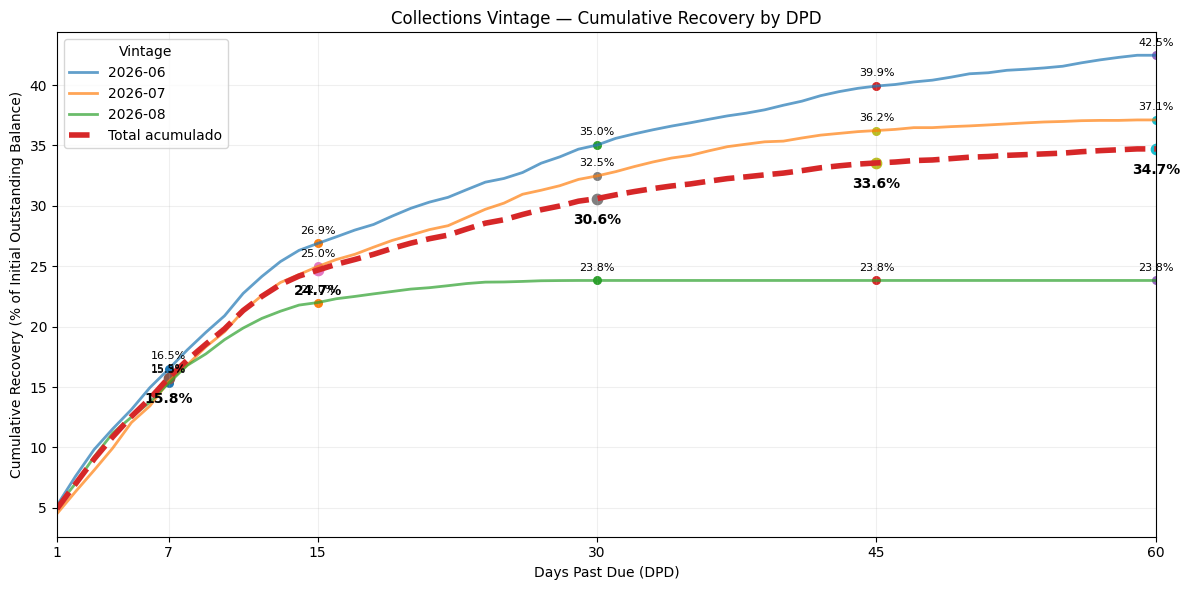

In [67]:
# ============================================================
# VINTAGE + TOTAL
# SAME METHODOLOGY FOR ALL CURVES
# ============================================================

plt.figure(figsize=(12, 6))


# ------------------------------------------------------------
# MONTHLY VINTAGES
# ------------------------------------------------------------

for vintage, g in recovery_vintage.groupby("vintage"):

    g = g.sort_values("day")

    plt.plot(
        g["day"],
        g["recovery_rate_pct"],
        linewidth=2,
        alpha=.70,
        label=str(vintage)
    )


# ------------------------------------------------------------
# TOTAL PORTFOLIO
# ------------------------------------------------------------

plt.plot(
    total_dpd_curve["day"],
    total_dpd_curve["recovery_rate_pct"],
    linewidth=4,
    linestyle="--",
    label="Total acumulado"
)


# ------------------------------------------------------------
# CHECKPOINT LABELS
# ------------------------------------------------------------

CHECKPOINTS_PLOT = [7, 15, 30, 45, 60]

for vintage, g in recovery_vintage.groupby("vintage"):

    for d in CHECKPOINTS_PLOT:

        row = g[g["day"] == d]

        if row.empty:
            continue

        y = row["recovery_rate_pct"].iloc[0]

        plt.scatter(
            d,
            y,
            s=30
        )

        plt.annotate(
            f"{y:.1f}%",
            (d, y),
            textcoords="offset points",
            xytext=(0, 7),
            ha="center",
            fontsize=8
        )


# ------------------------------------------------------------
# TOTAL LABELS
# ------------------------------------------------------------

for d in CHECKPOINTS_PLOT:

    row = total_dpd_curve[
        total_dpd_curve["day"] == d
    ]

    if row.empty:
        continue

    y = row["recovery_rate_pct"].iloc[0]

    plt.scatter(
        d,
        y,
        s=55
    )

    plt.annotate(
        f"{y:.1f}%",
        (d, y),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )


# ------------------------------------------------------------
# FORMAT
# ------------------------------------------------------------

plt.title(
    "Collections Vintage — Cumulative Recovery by DPD"
)

plt.xlabel(
    "Days Past Due (DPD)"
)

plt.ylabel(
    "Cumulative Recovery (% of Initial Outstanding Balance)"
)

plt.xticks(
    [1, 7, 15, 30, 45, 60]
)

plt.xlim(1, 60)

plt.legend(
    title="Vintage"
)

plt.grid(alpha=.2)

plt.tight_layout()

plt.show()

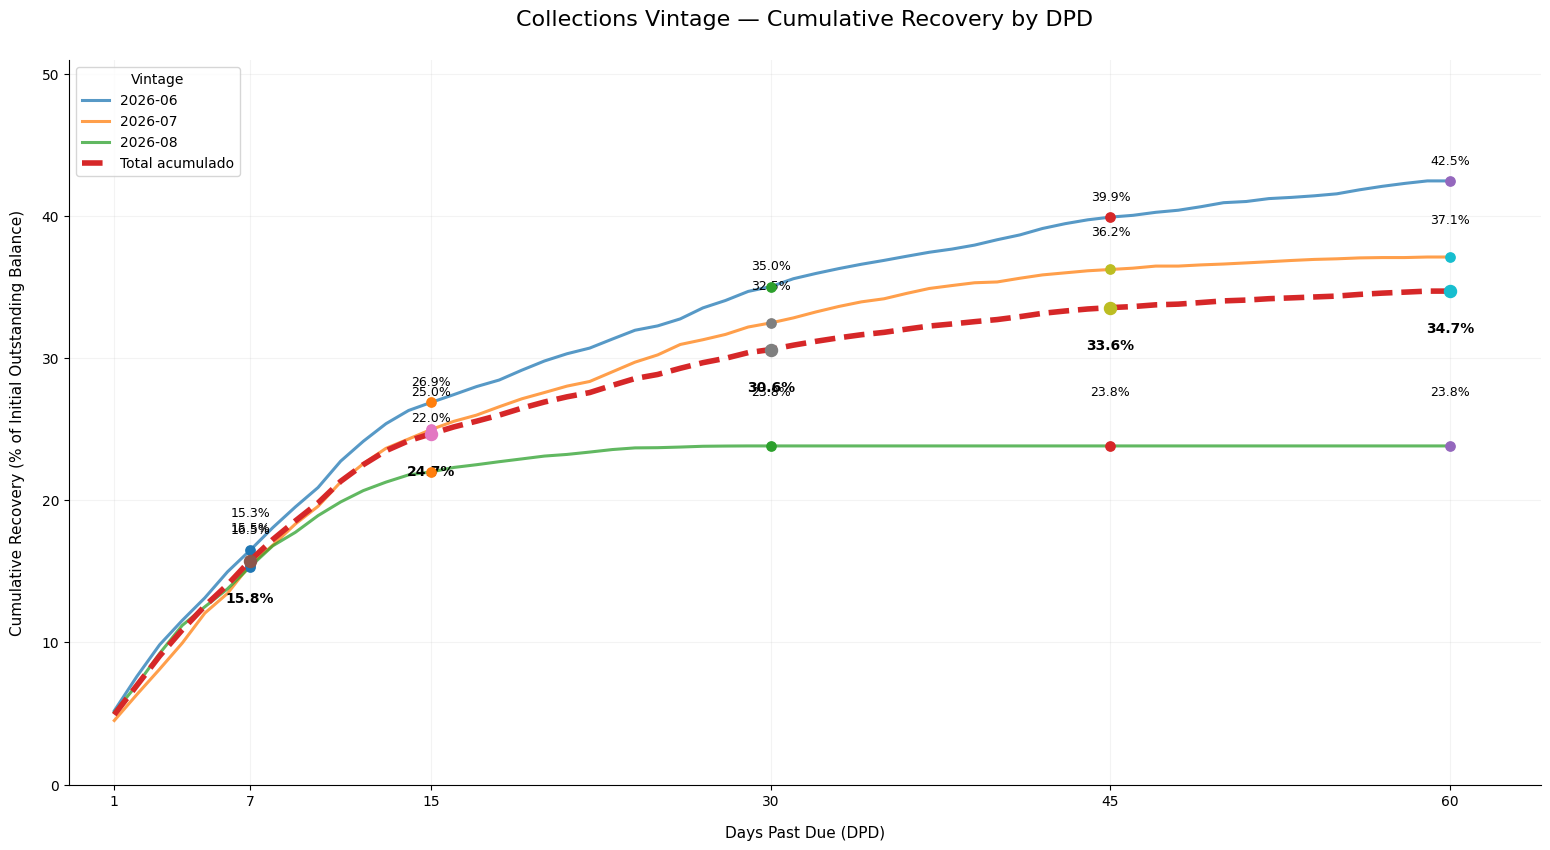

In [68]:
# ============================================================
# VINTAGE + TOTAL — PRESENTATION READY
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

CHECKPOINTS_PLOT = [7, 15, 30, 45, 60]

fig, ax = plt.subplots(
    figsize=(16, 9)
)


# ------------------------------------------------------------
# MONTHLY VINTAGES
# ------------------------------------------------------------

# Different vertical offsets avoid overlapping labels
label_offsets = {
    vintage: offset
    for vintage, offset in zip(
        sorted(recovery_vintage["vintage"].unique()),
        [10, 22, 34]
    )
}


for vintage, g in recovery_vintage.groupby("vintage"):

    g = g.sort_values("day")

    ax.plot(
        g["day"],
        g["recovery_rate_pct"],
        linewidth=2.2,
        alpha=.75,
        label=str(vintage)
    )

    # --------------------------------------------------------
    # Checkpoint markers + labels
    # --------------------------------------------------------

    for d in CHECKPOINTS_PLOT:

        row = g[g["day"] == d]

        if row.empty:
            continue

        y = row["recovery_rate_pct"].iloc[0]

        ax.scatter(
            d,
            y,
            s=45,
            zorder=5
        )

        ax.annotate(
            f"{y:.1f}%",
            xy=(d, y),
            xytext=(
                0,
                label_offsets[vintage]
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            annotation_clip=False
        )


# ------------------------------------------------------------
# TOTAL PORTFOLIO
# ------------------------------------------------------------

ax.plot(
    total_dpd_curve["day"],
    total_dpd_curve["recovery_rate_pct"],
    linewidth=4,
    linestyle="--",
    label="Total acumulado",
    zorder=6
)


# ------------------------------------------------------------
# TOTAL CHECKPOINT LABELS
# ------------------------------------------------------------

for d in CHECKPOINTS_PLOT:

    row = total_dpd_curve[
        total_dpd_curve["day"] == d
    ]

    if row.empty:
        continue

    y = row["recovery_rate_pct"].iloc[0]

    ax.scatter(
        d,
        y,
        s=75,
        zorder=7
    )

    ax.annotate(
        f"{y:.1f}%",
        xy=(d, y),
        xytext=(0, -22),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        annotation_clip=False
    )


# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

ax.set_title(
    "Collections Vintage — Cumulative Recovery by DPD",
    fontsize=16,
    pad=25
)

ax.set_xlabel(
    "Days Past Due (DPD)",
    fontsize=11,
    labelpad=12
)

ax.set_ylabel(
    "Cumulative Recovery (% of Initial Outstanding Balance)",
    fontsize=11,
    labelpad=12
)


# Give extra horizontal space so DPD 60 labels don't get cut
ax.set_xlim(
    -1,
    64
)


# Give extra vertical space for annotations
y_max = max(
    recovery_vintage["recovery_rate_pct"].max(),
    total_dpd_curve["recovery_rate_pct"].max()
)

ax.set_ylim(
    0,
    y_max * 1.20
)


ax.set_xticks(
    [1, 7, 15, 30, 45, 60]
)


# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------

ax.legend(
    title="Vintage",
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=10
)


# ------------------------------------------------------------
# GRID
# ------------------------------------------------------------

ax.grid(
    alpha=.15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# LAYOUT
# ------------------------------------------------------------

plt.tight_layout(
    pad=2.5
)

plt.show()

In [69]:
# ============================================================
# VINTAGE — % OF TOTAL RECOVERY CAPTURED BY DPD
# ============================================================

results_capture = []

for vintage in sorted(
    customers["vintage_month"].dropna().unique()
):

    # --------------------------------------------------------
    # Fixed population for vintage
    # --------------------------------------------------------

    vintage_customers = customers[
        customers["vintage_month"] == vintage
    ].copy()

    vintage_ids = vintage_customers["customer_id"]


    # --------------------------------------------------------
    # TOTAL recovery of this vintage
    # This is the FIXED denominator
    # --------------------------------------------------------

    vintage_total_recovery = (
        df.loc[
            df["customer_id"].isin(vintage_ids),
            "amount_paid_brl"
        ]
        .fillna(0)
        .sum()
    )


    # --------------------------------------------------------
    # Curve DPD 1 → 60
    # --------------------------------------------------------

    for d in range(1, 61):

        cumulative_recovery = (
            df.loc[
                df["customer_id"].isin(vintage_ids)
                &
                (df["days_since_entry"] <= d),
                "amount_paid_brl"
            ]
            .fillna(0)
            .sum()
        )


        recovery_capture_pct = (
            100
            * cumulative_recovery
            / vintage_total_recovery
            if vintage_total_recovery > 0
            else np.nan
        )


        results_capture.append({

            "vintage": vintage,

            "day": d,

            "total_recovery_brl":
                vintage_total_recovery,

            "cumulative_recovery_brl":
                cumulative_recovery,

            "recovery_capture_pct":
                recovery_capture_pct
        })


recovery_capture_vintage = pd.DataFrame(
    results_capture
)

In [70]:
# ============================================================
# TOTAL PORTFOLIO — % OF TOTAL RECOVERY CAPTURED BY DPD
# ============================================================

portfolio_total_recovery = (
    df["amount_paid_brl"]
    .fillna(0)
    .sum()
)

results_total_capture = []

for d in range(1, 61):

    cumulative_recovery = (
        df.loc[
            df["days_since_entry"] <= d,
            "amount_paid_brl"
        ]
        .fillna(0)
        .sum()
    )


    recovery_capture_pct = (
        100
        * cumulative_recovery
        / portfolio_total_recovery
        if portfolio_total_recovery > 0
        else np.nan
    )


    results_total_capture.append({

        "day": d,

        "total_recovery_brl":
            portfolio_total_recovery,

        "cumulative_recovery_brl":
            cumulative_recovery,

        "recovery_capture_pct":
            recovery_capture_pct
    })


total_capture_curve = pd.DataFrame(
    results_total_capture
)

In [71]:
CHECKPOINTS_PLOT = [7, 15, 30, 45, 60]

print("=" * 100)
print("TOTAL PORTFOLIO")
print("=" * 100)

display(
    total_capture_curve[
        total_capture_curve["day"].isin(
            CHECKPOINTS_PLOT
        )
    ].round(2)
)


print("\n" + "=" * 100)
print("BY VINTAGE")
print("=" * 100)

display(
    recovery_capture_vintage[
        recovery_capture_vintage["day"].isin(
            CHECKPOINTS_PLOT
        )
    ][
        [
            "vintage",
            "day",
            "total_recovery_brl",
            "cumulative_recovery_brl",
            "recovery_capture_pct"
        ]
    ].round(2)
)

TOTAL PORTFOLIO


,day,total_recovery_brl,cumulative_recovery_brl,recovery_capture_pct
6,7,"3,459,305.30","1,570,858.13",45.41
14,15,"3,459,305.30","2,459,308.12",71.09
29,30,"3,459,305.30","3,049,653.12",88.16
44,45,"3,459,305.30","3,343,549.02",96.65
59,60,"3,459,305.30","3,459,305.30",100.00



BY VINTAGE


,vintage,day,total_recovery_brl,cumulative_recovery_brl,recovery_capture_pct
6,2026-06,7,"1,422,950.51","552,410.77",38.82
14,2026-06,15,"1,422,950.51","900,959.34",63.32
29,2026-06,30,"1,422,950.51","1,173,910.96",82.50
44,2026-06,45,"1,422,950.51","1,337,596.51",94.00
59,2026-06,60,"1,422,950.51","1,422,950.51",100.00
66,2026-07,7,"1,286,263.19","535,967.90",41.67
74,2026-07,15,"1,286,263.19","865,812.16",67.31
89,2026-07,30,"1,286,263.19","1,125,650.56",87.51
104,2026-07,45,"1,286,263.19","1,255,860.91",97.64
119,2026-07,60,"1,286,263.19","1,286,263.19",100.00


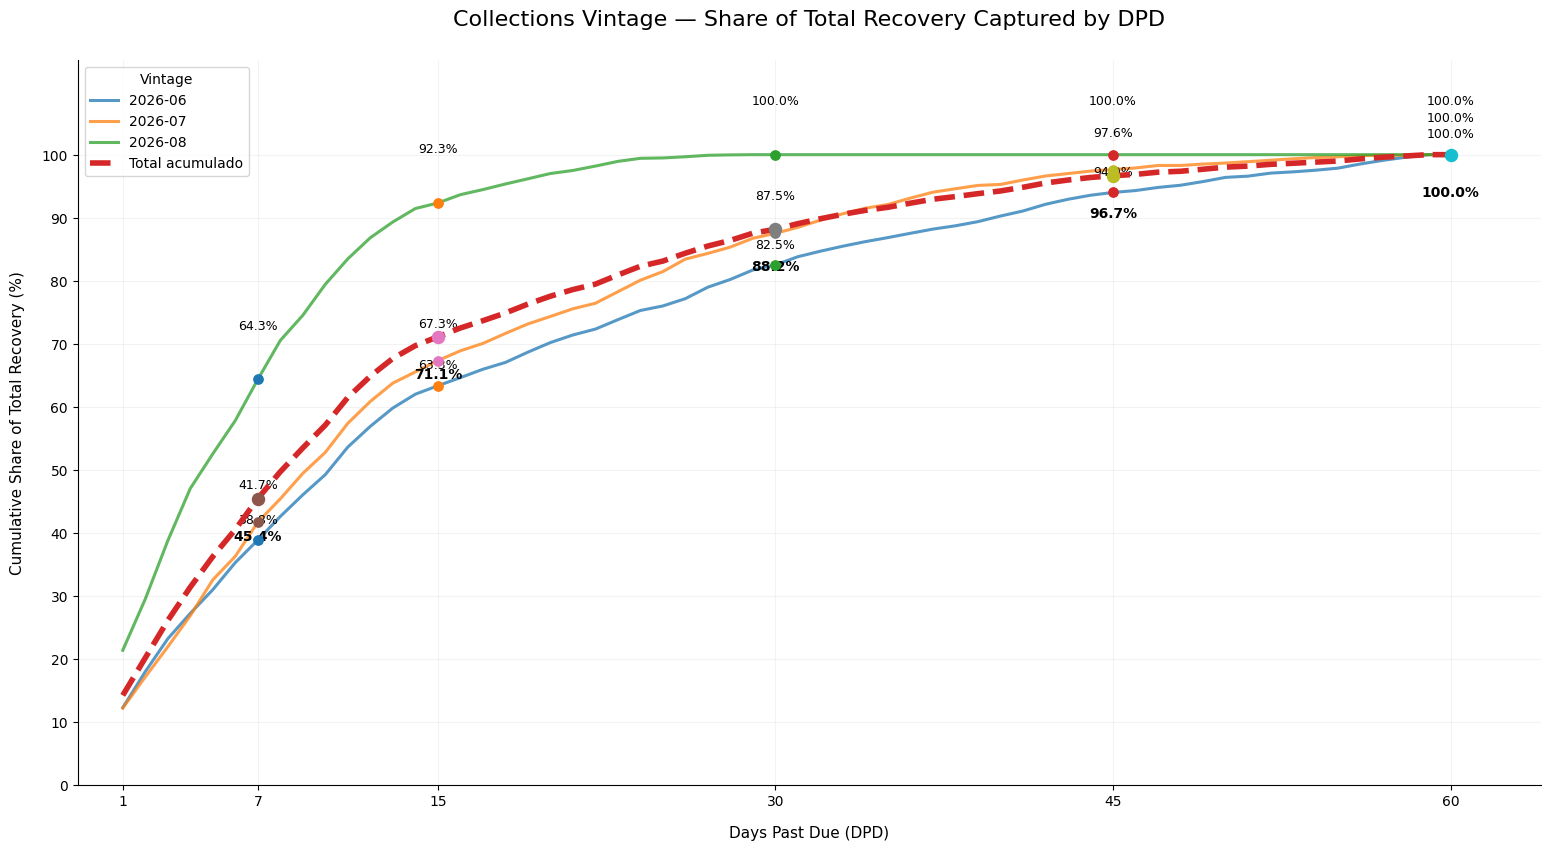

In [73]:
# ============================================================
# VINTAGE — % OF TOTAL RECOVERY CAPTURED BY DPD
# ============================================================

import matplotlib.pyplot as plt

CHECKPOINTS_PLOT = [7, 15, 30, 45, 60]

fig, ax = plt.subplots(
    figsize=(16, 9)
)


# ------------------------------------------------------------
# Label offsets
# ------------------------------------------------------------

label_offsets = {
    vintage: offset
    for vintage, offset in zip(
        sorted(
            recovery_capture_vintage[
                "vintage"
            ].unique()
        ),
        [10, 22, 34]
    )
}


# ------------------------------------------------------------
# MONTHLY VINTAGES
# ------------------------------------------------------------

for vintage, g in recovery_capture_vintage.groupby(
    "vintage"
):

    g = g.sort_values("day")

    ax.plot(
        g["day"],
        g["recovery_capture_pct"],
        linewidth=2.2,
        alpha=.75,
        label=str(vintage)
    )


    # Checkpoints
    for d in CHECKPOINTS_PLOT:

        row = g[
            g["day"] == d
        ]

        if row.empty:
            continue

        y = row[
            "recovery_capture_pct"
        ].iloc[0]


        ax.scatter(
            d,
            y,
            s=45,
            zorder=5
        )


        ax.annotate(
            f"{y:.1f}%",
            xy=(d, y),
            xytext=(
                0,
                label_offsets[vintage]
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            annotation_clip=False
        )


# ------------------------------------------------------------
# TOTAL PORTFOLIO
# ------------------------------------------------------------

ax.plot(
    total_capture_curve["day"],
    total_capture_curve[
        "recovery_capture_pct"
    ],
    linewidth=4,
    linestyle="--",
    label="Total acumulado",
    zorder=6
)


# ------------------------------------------------------------
# TOTAL LABELS
# ------------------------------------------------------------

for d in CHECKPOINTS_PLOT:

    row = total_capture_curve[
        total_capture_curve["day"] == d
    ]

    if row.empty:
        continue

    y = row[
        "recovery_capture_pct"
    ].iloc[0]


    ax.scatter(
        d,
        y,
        s=75,
        zorder=7
    )


    ax.annotate(
        f"{y:.1f}%",
        xy=(d, y),
        xytext=(0, -22),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        annotation_clip=False
    )


# ------------------------------------------------------------
# FORMAT
# ------------------------------------------------------------

ax.set_title(
    "Collections Vintage — Share of Total Recovery Captured by DPD",
    fontsize=16,
    pad=25
)

ax.set_xlabel(
    "Days Past Due (DPD)",
    fontsize=11,
    labelpad=12
)

ax.set_ylabel(
    "Cumulative Share of Total Recovery (%)",
    fontsize=11,
    labelpad=12
)


ax.set_xlim(
    -1,
    64
)

# Here 100% has a natural meaning
# Give annotation labels some room above it
ax.set_ylim(
    0,
    115
)

ax.set_xticks(
    [1, 7, 15, 30, 45, 60]
)

ax.set_yticks(
    range(0, 101, 10)
)


ax.legend(
    title="Vintage",
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=10
)


ax.grid(
    alpha=.15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(
    pad=2.5
)

plt.show()

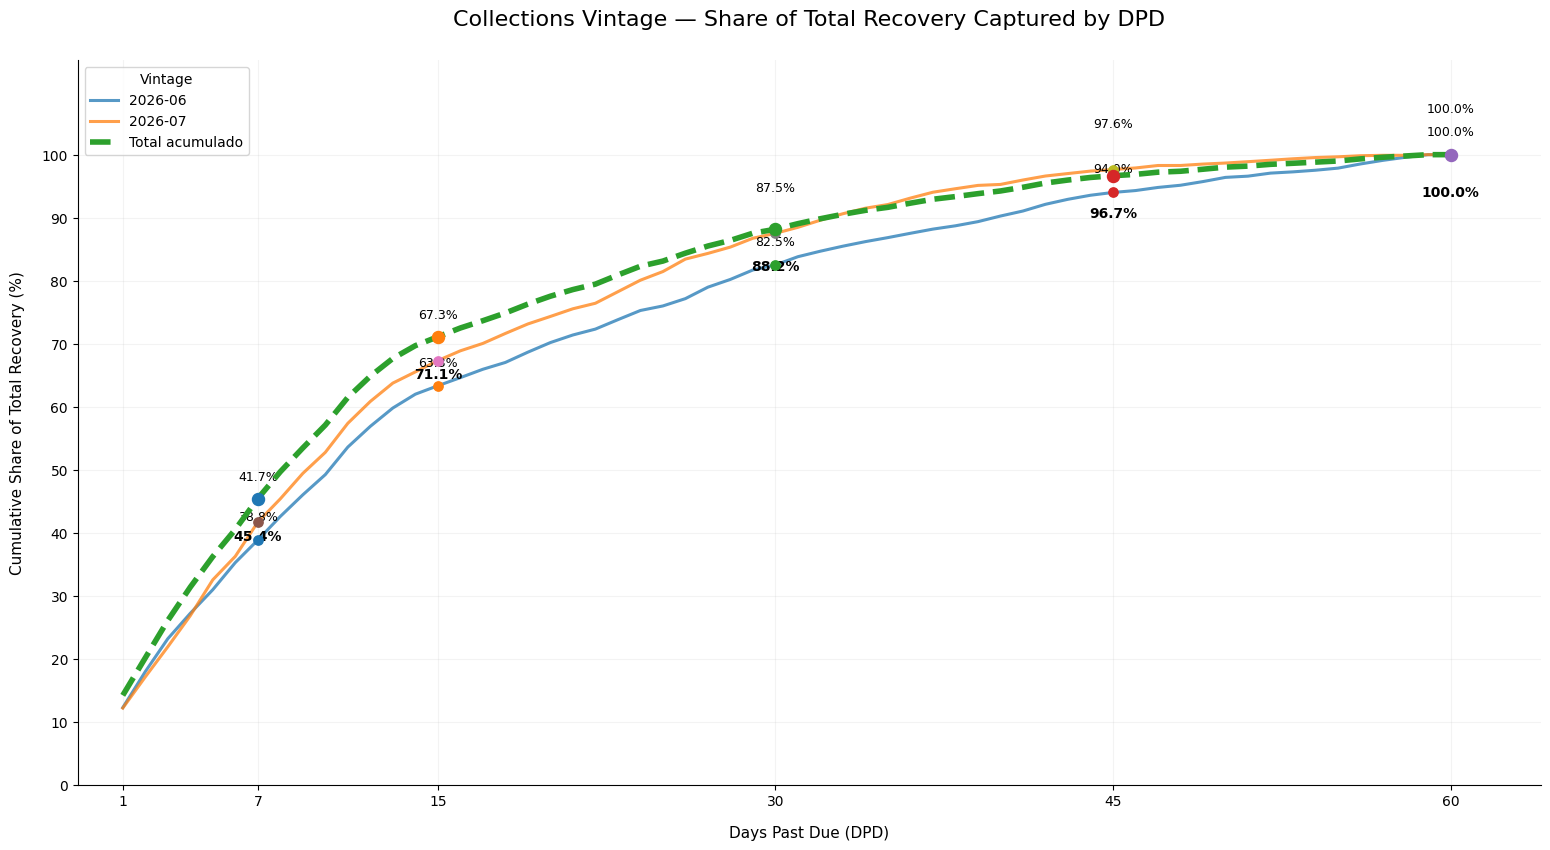

In [75]:
# ============================================================
# VINTAGE — % OF TOTAL RECOVERY CAPTURED BY DPD
# JUN + JUL + TOTAL
# August removed only from monthly vintage curves
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIG
# ============================================================

CHECKPOINTS_PLOT = [7, 15, 30, 45, 60]


# ============================================================
# 2. REMOVE AUGUST FROM MONTHLY VINTAGE CURVES
# ============================================================

recovery_capture_plot = recovery_capture_vintage[
    recovery_capture_vintage["vintage"].astype(str) != "2026-08"
].copy()


# ============================================================
# 3. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9)
)


# ============================================================
# 4. LABEL OFFSETS
#    Separate Jun and Jul labels vertically
# ============================================================

vintages_plot = sorted(
    recovery_capture_plot["vintage"].unique()
)

label_offsets = {
    vintage: offset
    for vintage, offset in zip(
        vintages_plot,
        [12, 28]
    )
}


# ============================================================
# 5. MONTHLY VINTAGE CURVES
#    JUN + JUL ONLY
# ============================================================

for vintage, g in recovery_capture_plot.groupby("vintage"):

    g = g.sort_values("day")

    # --------------------------------------------------------
    # Curve
    # --------------------------------------------------------

    ax.plot(
        g["day"],
        g["recovery_capture_pct"],
        linewidth=2.2,
        alpha=.75,
        label=str(vintage)
    )


    # --------------------------------------------------------
    # Checkpoint markers + labels
    # --------------------------------------------------------

    for d in CHECKPOINTS_PLOT:

        row = g[
            g["day"] == d
        ]

        if row.empty:
            continue

        y = row[
            "recovery_capture_pct"
        ].iloc[0]


        ax.scatter(
            d,
            y,
            s=45,
            zorder=5
        )


        ax.annotate(
            f"{y:.1f}%",
            xy=(d, y),
            xytext=(
                0,
                label_offsets[vintage]
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            annotation_clip=False
        )


# ============================================================
# 6. TOTAL PORTFOLIO
#    Includes the complete portfolio
# ============================================================

ax.plot(
    total_capture_curve["day"],
    total_capture_curve[
        "recovery_capture_pct"
    ],
    linewidth=4,
    linestyle="--",
    label="Total acumulado",
    zorder=6
)


# ============================================================
# 7. TOTAL CHECKPOINT MARKERS + LABELS
# ============================================================

for d in CHECKPOINTS_PLOT:

    row = total_capture_curve[
        total_capture_curve["day"] == d
    ]

    if row.empty:
        continue

    y = row[
        "recovery_capture_pct"
    ].iloc[0]


    ax.scatter(
        d,
        y,
        s=75,
        zorder=7
    )


    ax.annotate(
        f"{y:.1f}%",
        xy=(d, y),
        xytext=(0, -22),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        annotation_clip=False
    )


# ============================================================
# 8. TITLE
# ============================================================

ax.set_title(
    "Collections Vintage — Share of Total Recovery Captured by DPD",
    fontsize=16,
    pad=25
)


# ============================================================
# 9. AXIS LABELS
# ============================================================

ax.set_xlabel(
    "Days Past Due (DPD)",
    fontsize=11,
    labelpad=12
)

ax.set_ylabel(
    "Cumulative Share of Total Recovery (%)",
    fontsize=11,
    labelpad=12
)


# ============================================================
# 10. AXIS LIMITS
# ============================================================

# Extra horizontal space so DPD 60 labels are not cut
ax.set_xlim(
    -1,
    64
)

# 100% is the natural maximum.
# Extra space above for annotations.
ax.set_ylim(
    0,
    115
)


# ============================================================
# 11. AXIS TICKS
# ============================================================

ax.set_xticks(
    [1, 7, 15, 30, 45, 60]
)

ax.set_yticks(
    range(0, 101, 10)
)


# ============================================================
# 12. LEGEND
# ============================================================

ax.legend(
    title="Vintage",
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=10
)


# ============================================================
# 13. GRID
# ============================================================

ax.grid(
    alpha=.15
)


# ============================================================
# 14. CLEAN VISUAL STYLE
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ============================================================
# 15. LAYOUT
# ============================================================

plt.tight_layout(
    pad=2.5
)

plt.show()

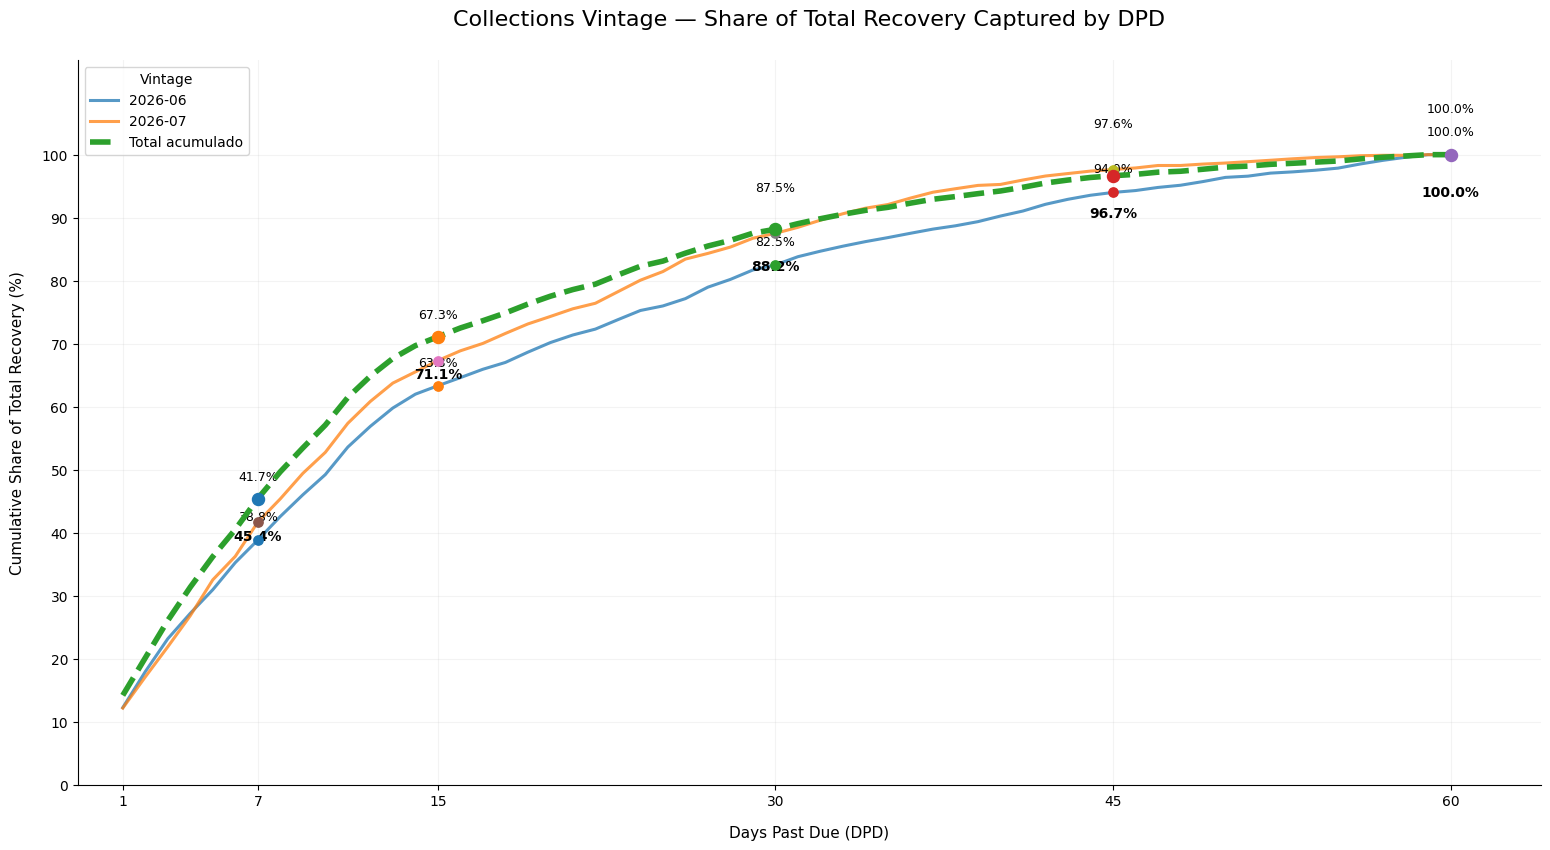

In [76]:
# ============================================================
# VINTAGE — % OF TOTAL RECOVERY CAPTURED BY DPD
# JUN + JUL + TOTAL
# August removed only from monthly vintage curves
# ============================================================

import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIG
# ============================================================

CHECKPOINTS_PLOT = [7, 15, 30, 45, 60]


# ============================================================
# 2. REMOVE AUGUST FROM MONTHLY VINTAGE CURVES
# ============================================================

recovery_capture_plot = recovery_capture_vintage[
    recovery_capture_vintage["vintage"].astype(str) != "2026-08"
].copy()


# ============================================================
# 3. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9)
)


# ============================================================
# 4. LABEL OFFSETS
#    Separate Jun and Jul labels vertically
# ============================================================

vintages_plot = sorted(
    recovery_capture_plot["vintage"].unique()
)

label_offsets = {
    vintage: offset
    for vintage, offset in zip(
        vintages_plot,
        [12, 28]
    )
}


# ============================================================
# 5. MONTHLY VINTAGE CURVES
#    JUN + JUL ONLY
# ============================================================

for vintage, g in recovery_capture_plot.groupby("vintage"):

    g = g.sort_values("day")

    # --------------------------------------------------------
    # Curve
    # --------------------------------------------------------

    ax.plot(
        g["day"],
        g["recovery_capture_pct"],
        linewidth=2.2,
        alpha=.75,
        label=str(vintage)
    )


    # --------------------------------------------------------
    # Checkpoint markers + labels
    # --------------------------------------------------------

    for d in CHECKPOINTS_PLOT:

        row = g[
            g["day"] == d
        ]

        if row.empty:
            continue

        y = row[
            "recovery_capture_pct"
        ].iloc[0]


        ax.scatter(
            d,
            y,
            s=45,
            zorder=5
        )


        ax.annotate(
            f"{y:.1f}%",
            xy=(d, y),
            xytext=(
                0,
                label_offsets[vintage]
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            annotation_clip=False
        )


# ============================================================
# 6. TOTAL PORTFOLIO
#    Includes the complete portfolio
# ============================================================

ax.plot(
    total_capture_curve["day"],
    total_capture_curve[
        "recovery_capture_pct"
    ],
    linewidth=4,
    linestyle="--",
    label="Total acumulado",
    zorder=6
)


# ============================================================
# 7. TOTAL CHECKPOINT MARKERS + LABELS
# ============================================================

for d in CHECKPOINTS_PLOT:

    row = total_capture_curve[
        total_capture_curve["day"] == d
    ]

    if row.empty:
        continue

    y = row[
        "recovery_capture_pct"
    ].iloc[0]


    ax.scatter(
        d,
        y,
        s=75,
        zorder=7
    )


    ax.annotate(
        f"{y:.1f}%",
        xy=(d, y),
        xytext=(0, -22),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        annotation_clip=False
    )


# ============================================================
# 8. TITLE
# ============================================================

ax.set_title(
    "Collections Vintage — Share of Total Recovery Captured by DPD",
    fontsize=16,
    pad=25
)


# ============================================================
# 9. AXIS LABELS
# ============================================================

ax.set_xlabel(
    "Days Past Due (DPD)",
    fontsize=11,
    labelpad=12
)

ax.set_ylabel(
    "Cumulative Share of Total Recovery (%)",
    fontsize=11,
    labelpad=12
)


# ============================================================
# 10. AXIS LIMITS
# ============================================================

# Extra horizontal space so DPD 60 labels are not cut
ax.set_xlim(
    -1,
    64
)

# 100% is the natural maximum.
# Extra space above for annotations.
ax.set_ylim(
    0,
    115
)


# ============================================================
# 11. AXIS TICKS
# ============================================================

ax.set_xticks(
    [1, 7, 15, 30, 45, 60]
)

ax.set_yticks(
    range(0, 101, 10)
)


# ============================================================
# 12. LEGEND
# ============================================================

ax.legend(
    title="Vintage",
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=10
)


# ============================================================
# 13. GRID
# ============================================================

ax.grid(
    alpha=.15
)


# ============================================================
# 14. CLEAN VISUAL STYLE
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ============================================================
# 15. LAYOUT
# ============================================================

plt.tight_layout(
    pad=2.5
)

plt.show()